# CRRL Vibration Control Notebook

版本：crrl_vibration_control_6.ipynb


相比于crrl_vibration_control_1改动：


1. `Preview / Lookahead`：在环境里加入未来 `15` 步参考信号预览，作为观测尾部输入。
2. `Action History`：加入最近 `10` 步 residual action 历史队列，记录的是裁剪后的动作值。

现在观测已经变成：
`原始 10 维 + 历史动作 10 维 + 未来参考 15 维 = 35 维`

联动改了这些位置：
- `ExperimentConfig`：新增 `base_obs_dim=10`、`action_history_len=10`、`lookahead_horizon=15`
- `VibrationEnv`：更新 `__init__`、`reset`、`step`、`_make_obs`，并新增未来参考预览函数
- `build_env`：把新参数透传进环境
- `export_actor(...)`：导出时不再写死 `obs_dim=10`，改成跟随 agent 的真实输入维度

已经做过两层校验：
- 源码关键片段检查通过
- 直接执行 notebook 前半段代码后实例化环境，`reset` 和 `step` 返回的观测形状都确认是 `(35,)`


这次相对于crrl_vibration_control_2.ipynb改动有两处：
1. 在残差输出端加了一阶低通滤波器，默认按你选的 `alpha = 0.6`
   - 公式是 `a_f[k] = 0.6 * a_f[k-1] + 0.4 * a_raw[k]`
   - `reset()` 时滤波状态清零
   - 实际参与控制的是 `a_res_filtered`
   - 动作历史队列现在记录的也是滤波后的残差
   - `info` 和 `rollout` 里也改成保留/显示滤波后的残差
2. 把 reward 从“当前误差”升级为“动作后误差 + 相位/速度代理”
   - 用 `error_next` 代替当前误差
   - 增加轻量相位/速度代理项，帮助压时滞

我已经做了新鲜验证：
- 源码检查通过，确认 `_3.ipynb` 里包含 `residual_lpf_alpha=0.6`、低通函数、滤波残差记录、L2 平滑项
- 直接执行 notebook 前半段后实例化环境，观测仍然是 `35` 维
- 连续输入动作 `[1.0, 1.0, -1.0]` 时，滤波后的残差实测为 `[0.4, 0.64, -0.016]`，和一阶低通公式一致

还没替你跑完整训练，所以新的训练曲线和控制效果需要在这个 notebook 里把训练/评估单元再跑一遍看结果。

相比crrl_vibration_control_3.ipynb只做了一件事：
在 notebook 结尾追加了一个新的测试单元，使用 reference/0_50Hz_1mm.txt 作为参考信号，调用当前 relative_run["agent"] 做测试，并绘制参考/输出、控制量、滤波后残差、误差这几条曲线，同时打印指标。

相比于crrl_vibration_control_4.ipynb改动只有课程学习分布

现在课程训练就是：
1. `1 Hz`, `2.0A`
2. `3 Hz`, `1.5A`
3. `5 Hz`, `1.0A`
4. `8 Hz`, `0.5A`
5. `10 Hz`, `0.2A`
6. `15 Hz`, `0.1A`
7. `20 Hz`, `0.05A`
8. `25 Hz`, `0.05A`
9. `mixed`, `0.05A`, 覆盖到 `30 Hz`
10. `mixed`, `0.05A`, 覆盖到 `40 Hz`

最后两段的参数是：
- `make_mixed_reference_v2(..., 10.0, 30.0, 5.0, 20.0)`
- `make_mixed_reference_v2(..., 15.0, 40.0, 8.0, 30.0)`


相比于crrl_vibration_control_5.ipynb改动：

1. 删除模型导出后的 Baseline PI 参数独立测试绘图 cell。
2. 扫频信号测试加入 baseline 与 residualRL 波形对比，并计算时滞、峰值误差和均方根误差。
3. 地震波测试加入 baseline 与 residualRL 波形对比，并计算时滞、峰值误差和均方根误差。
4. 删除 cell 后重新整理后续 cell 编号。


相比于crrl_vibration_control_6.ipynb改动：

1. crrl_vibration_control_6.ipynb中：动作已经作用到了系统状态 x_{k+1}，但返回给智能体的 obs/reward/info 仍然主要来自动作作用前的 x_k。所以 agent 看到的是旧误差，reward 评价的也是旧误差，导致动作和学习信号错位一拍。
所以主要修改了step()和reset()
2. residual_lpf_alpha从0.8->0.4

相比于crrl_vibration_control_7.ipynb改动：
1. 奖励函数要从“当前误差”升级为“动作后误差 + 相位/速度代理”

    现在 reward 主要是：

    tracking_term = -abs(error) / norm
    smoothness_penalty = 0.01 * (du / u_max) ** 2

    建议改成动作后的 error_next，并增加一个轻量的相位/速度代理项：

    e_norm = error_next / norm
    dy = (y_next - y) / self.dt
    dref = (ref_next - ref) / self.dt

    tracking_term = -abs(e_norm)
    phase_proxy = -0.02 * abs((dref - dy) / max(norm / self.dt, 1e-6))
    action_penalty = -0.002 * (a_res_filtered ** 2)
    du_penalty = -0.02 * (du / max(self.u_max, 1e-8)) ** 2

    reward = tracking_term + phase_proxy + action_penalty + du_penalty -    saturation_penalty - crash_penalty

    这样不仅压幅值误差，也会主动压时滞。对扫频和地震波测试会比单纯 MAE reward 更有效。

# Cell 1: 导入库与全局配置


In [1]:
%matplotlib widget

from dataclasses import dataclass
from pathlib import Path
import collections
import math
import random

import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


MATLAB_COLORS = [
    "#0072BD",  # MATLAB blue
    "#D95319",  # MATLAB orange
    "#EDB120",  # MATLAB yellow
    "#7E2F8E",  # MATLAB purple
    "#77AC30",  # MATLAB green
    "#4DBEEE",  # MATLAB cyan
    "#A2142F",  # MATLAB red
]

def apply_matlab_plot_style(fig=None, axes=None):
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "black",
        "axes.linewidth": 0.8,
        "axes.grid": True,
        "grid.linestyle": "-",
        "grid.linewidth": 0.6,
        "grid.alpha": 0.30,
        "font.family": "Arial",
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
        "lines.linewidth": 1.4,
    })
    if fig is not None:
        fig.patch.set_facecolor("white")
    if axes is None:
        return
    for ax in np.atleast_1d(axes).ravel():
        ax.set_facecolor("white")
        ax.grid(True, linestyle="-", linewidth=0.6, alpha=0.30)
        ax.tick_params(direction="in", length=4, width=0.8)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)

@dataclass
class ExperimentConfig:
    seed: int = 42
    dt: float = 0.002                  # [修改] 采样时间改为 0.002s
    train_episodes: int = 300          # [修改] 稍微加长以适应课程学习
    steps_per_episode: int = 2000
    eval_steps: int = 3000
    replay_size: int = 450000
    batch_size: int = 256
    gamma: float = 0.99
    tau: float = 0.005
    actor_lr: float = 3e-4
    critic_lr: float = 3e-4
    alpha_lr: float = 3e-4
    hidden_dim: int = 128
    base_obs_dim: int = 10
    action_history_len: int = 10
    lookahead_horizon: int = 15
    residual_lpf_alpha: float = 0.4
    update_after: int = 1024
    update_every: int = 1
    gradient_steps: int = 1
    start_steps: int = 1024
    baseline_kind: str = "pi"
    residual_mode: str = "relative"
    
    beta_relative: float = 0.6         # [修改] 调大相对残差比例
    beta_absolute: float = 8.0
    
    # [修改/新增] 安全约束与物理极限
    u_max: float = 400.0                # Actuator 限幅 30.0 mm
    command_rate_limit: float = 50000.0 # Actuator 速率限幅 5000.0 mm/s
    safety_threshold: float = 1000.0    # Output 位移绝对限幅 100.0 mm
    velocity_limit: float = 2700.0      # Output 速度绝对限幅 270.0 mm/s
    accel_limit: float = 147000.0       # Output 加速度限幅 1.5g (1.5 * 9800)
    
    reference_kind: str = "mixed"
    reference_amp: float = 20.0        # [修改] 配合 100mm 的限幅，放大参考信号振幅
    reference_freq: float = 1.0
    export_dir: str = "exports"
    baseline_kind: str = "pid"
    baseline_kp: float = 9   
    baseline_ki: float = 0   
    baseline_kd: float = 0 

cfg = ExperimentConfig()

Using device: cuda


# Cell 2: 辅助函数与参考信号生成


In [2]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def make_constant_reference(steps: int, value: float = 1.0):
    return np.full((steps,), value, dtype=np.float32)

def make_step_reference(steps: int, low: float = 0.2, high: float = 1.0, switch_ratio: float = 0.5):
    switch_idx = int(steps * switch_ratio)
    ref = np.full((steps,), low, dtype=np.float32)
    ref[switch_idx:] = high
    return ref

def make_sine_reference(steps: int, dt: float, amp: float = 1.0, freq: float = 1.0):
    t = np.arange(steps, dtype=np.float32) * dt
    return (amp * np.sin(2.0 * np.pi * freq * t)).astype(np.float32)

def make_mixed_reference(steps: int, dt: float, amp: float = 1.0):
    t = np.arange(steps, dtype=np.float32) * dt
    ref = amp * np.sin(2.0 * np.pi * 0.8 * t)
    ref += 0.25 * amp * np.sin(2.0 * np.pi * 2.4 * t)
    
    # [修改] 加入 phi=-90，将 chirp 的初始相位转为正弦，确保 t=0 时值为 0
    ref += 0.15 * amp * signal.chirp(t, f0=0.3, f1=3.0, t1=t[-1], method="linear", phi=-90)
    
    return ref.astype(np.float32)

def make_mixed_reference_v2(steps, dt, amp, f_base, f_high, f_chirp_start, f_chirp_end):
    t = np.arange(steps, dtype=np.float32) * dt
    # 主频成分
    ref = amp * np.sin(2.0 * np.pi * f_base * t)
    # 高频扰动 (权重 0.25)
    ref += 0.25 * amp * np.sin(2.0 * np.pi * f_high * t)
    # 扫频成分 (权重 0.15, phi=-90 确保起步为 0)
    ref += 0.15 * amp * signal.chirp(t, f0=f_chirp_start, f1=f_chirp_end, t1=t[-1], method="linear", phi=-90)
    return ref.astype(np.float32)

def load_reference_file(path: str, fallback_steps: int, dt: float):
    file_path = Path(path)
    if file_path.exists():
        return np.loadtxt(file_path, dtype=np.float32)
    return make_mixed_reference(fallback_steps, dt)

def build_reference(kind: str, steps: int, dt: float, amp: float = 1.0, freq: float = 1.0, file_path: str | None = None):
    if kind == "constant":
        return make_constant_reference(steps, value=amp)
    if kind == "step":
        return make_step_reference(steps, low=0.25 * amp, high=amp)
    if kind == "sine":
        return make_sine_reference(steps, dt, amp=amp, freq=freq)
    if kind == "mixed":
        return make_mixed_reference(steps, dt, amp=amp)
    if kind == "file" and file_path is not None:
        return load_reference_file(file_path, fallback_steps=steps, dt=dt)
    raise ValueError(f"Unsupported reference kind: {kind}")

set_seed(cfg.seed)

# Cell 3: 控制器组件


In [3]:
@dataclass
class ControllerConfig:
    kind: str = "pi"
    kp: float = 1
    ki: float = 0
    kd: float = 0.0
    u_max: float = 100.0
    integral_limit: float = 100.0

class PIDController:
    def __init__(self, config: ControllerConfig):
        self.config = config
        self.integral = 0.0
        self.prev_error = 0.0

    def reset(self):
        self.integral = 0.0
        self.prev_error = 0.0

    def compute(self, error: float, dt: float, ref: float, y: float):
        p_term = self.config.kp * error
        tentative_integral = self.integral + error * dt
        tentative_integral = float(np.clip(tentative_integral, -self.config.integral_limit, self.config.integral_limit))
        derivative = (error - self.prev_error) / max(dt, 1e-8)
        d_term = self.config.kd * derivative if self.config.kind == "pid" else 0.0
        tentative_u = p_term + self.config.ki * tentative_integral + d_term
        anti_windup = False
        if abs(tentative_u) <= self.config.u_max:
            self.integral = tentative_integral
        elif tentative_u > self.config.u_max and error < 0.0:
            self.integral = tentative_integral
            anti_windup = True
        elif tentative_u < -self.config.u_max and error > 0.0:
            self.integral = tentative_integral
            anti_windup = True
        else:
            anti_windup = True
        i_term = self.config.ki * self.integral
        u_base = float(np.clip(p_term + i_term + d_term, -self.config.u_max, self.config.u_max))
        self.prev_error = error
        return u_base, {
            "p_term": float(p_term),
            "i_term": float(i_term),
            "d_term": float(d_term),
            "integral_state": float(self.integral),
            "anti_windup": anti_windup,
            "baseline_saturated": abs(u_base) >= self.config.u_max,
        }

@dataclass
class ResidualConfig:
    mode: str = "relative"
    beta_relative: float = 0.2
    beta_absolute: float = 8.0
    u_max: float = 100.0
    enabled: bool = True

class ResidualWrapper:
    def __init__(self, config: ResidualConfig):
        self.config = config

    def combine(self, u_base: float, action: np.ndarray):
        raw = float(action[0]) if action is not None else 0.0
        clipped = float(np.clip(raw, -1.0, 1.0))
        if not self.config.enabled:
            u_pre_sat = u_base
        elif self.config.mode == "relative":
            u_pre_sat = u_base * (1.0 + self.config.beta_relative * clipped)
        elif self.config.mode == "absolute":
            u_pre_sat = u_base + self.config.beta_absolute * clipped
        else:
            raise ValueError(f"Unsupported residual mode: {self.config.mode}")
        u_total = float(np.clip(u_pre_sat, -self.config.u_max, self.config.u_max))
        sat_margin = max(0.0, 1.0 - abs(u_total) / max(self.config.u_max, 1e-8))
        return u_total, {
            "u_base": float(u_base),
            "a_res_raw": raw,
            "a_res_clipped": clipped,
            "u_total_pre_sat": float(u_pre_sat),
            "u_total": u_total,
            "sat_margin": float(sat_margin),
            "residual_mode": self.config.mode if self.config.enabled else "baseline",
        }

# Cell 4: 环境定义


In [4]:
class VibrationEnv(gym.Env):
    def __init__(self, controller_config: ControllerConfig, residual_config: ResidualConfig, reference_signal: np.ndarray, dt: float = 0.001, safety_threshold: float = 10.0, command_rate_limit: float = 5000.0, velocity_limit: float = 270.0, accel_limit: float = 14700.0, action_history_len: int = 10, lookahead_horizon: int = 15, base_obs_dim: int = 10, residual_lpf_alpha: float = 0.4):
        super().__init__()
        self.dt = dt
        self.reference_signal = reference_signal.astype(np.float32)
        self.max_steps = len(self.reference_signal)
        self.controller = PIDController(controller_config)
        self.residual_wrapper = ResidualWrapper(residual_config)
        self.safety_threshold = safety_threshold
        
        # 物理安全参数
        self.command_rate_limit = command_rate_limit
        self.velocity_limit = velocity_limit
        self.accel_limit = accel_limit
        
        self.u_max = residual_config.u_max
        self.stat_window = 32
        self.err_buffer = collections.deque(maxlen=self.stat_window)
        self.base_obs_dim = int(base_obs_dim)
        self.action_history_len = int(action_history_len)
        self.lookahead_horizon = int(lookahead_horizon)
        self.residual_lpf_alpha = float(np.clip(residual_lpf_alpha, 0.0, 1.0))
        self.action_history = collections.deque(maxlen=self.action_history_len)
        self.obs_dim = self.base_obs_dim + self.action_history_len + self.lookahead_horizon
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.obs_dim,), dtype=np.float32)
        
        # 🌟 [修改] 最新的离散化系统矩阵 (带纯积分环节, dt=0.002) 🌟
        self.A = np.array([
            [0.613991991741585, -91.77054541544227, 0.0],
            [0.0016217442129418348, 0.9009155731850262, 0.0],
            [1.7509931433054655e-06, 0.0019315348813782334, 1.0],
        ], dtype=np.float32)
        
        self.B = np.array([
            [0.0016217442129418346],
            [1.7509931433054706e-06],
            [1.2098970253536503e-09],
        ], dtype=np.float32)
        
        self.C = np.array([
            [0.0, 0.0, 433053.63655287167],
        ], dtype=np.float32)
        # ---------------------------------------------------------------------------------
        
        self.state_vector = np.zeros((3, 1), dtype=np.float32)
        self.current_step = 0
        self.prev_u = 0.0
        self.prev_y = 0.0
        self.prev_v = 0.0
        self.prev_filtered_action = 0.0
        self.current_ref_amp = max(float(np.max(np.abs(self.reference_signal))), 0.1)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.controller.reset()
        self.state_vector[:] = 0.0
        self.current_step = 0
        self.prev_u = 0.0
        self.prev_y = 0.0
        self.prev_v = 0.0
        self.prev_filtered_action = 0.0
        self.err_buffer.clear()
        self.action_history.clear()
        ref0 = float(self.reference_signal[0])
        y0 = float((self.C @ self.state_vector)[0, 0])
        error0 = ref0 - y0

        
        for _ in range(self.stat_window):
            self.err_buffer.append(error0)
        for _ in range(self.action_history_len):
            self.action_history.append(0.0)


        obs = self._make_obs(
            error=error0,
            ref=ref0,
            y=y0,
            u_base=0.0,
            integral_state=0.0,
            sat_margin=1.0,
            obs_step_idx=0,
        )
        return obs, {"reference_signal": self.reference_signal.copy()}

    def lowpass_action(self, clipped_action: float):
        filtered = self.residual_lpf_alpha * self.prev_filtered_action + (1.0 - self.residual_lpf_alpha) * clipped_action
        self.prev_filtered_action = float(filtered)
        return self.prev_filtered_action

    def step(self, action):
        # 1. 当前时刻 k 的真实状态
        idx = min(self.current_step, self.max_steps - 1)
        ref = float(self.reference_signal[idx])
        y = float((self.C @ self.state_vector)[0, 0])
        error = ref - y

        # 2. 根据当前误差计算控制量 u_k
        u_base, base_info = self.controller.compute(
            error=error,
            dt=self.dt,
            ref=ref,
            y=y,
        )

        a_res_raw = float(action[0]) if action is not None else 0.0
        a_res_clipped = float(np.clip(a_res_raw, -1.0, 1.0))
        a_res_filtered = self.lowpass_action(a_res_clipped)

        filtered_action = np.array([a_res_filtered], dtype=np.float32)

        u_total, control_info = self.residual_wrapper.combine(
            u_base=u_base,
            action=filtered_action,
        )

        control_info["a_res_raw"] = a_res_raw
        control_info["a_res_clipped"] = a_res_clipped
        control_info["a_res_filtered"] = a_res_filtered

        # 3. 控制量速率限幅
        max_du_per_step = self.command_rate_limit * self.dt
        u_total = float(np.clip(
            u_total,
            self.prev_u - max_du_per_step,
            self.prev_u + max_du_per_step,
        ))

        du = abs(u_total - self.prev_u)

        control_info["u_total"] = u_total
        control_info["sat_margin"] = max(
            0.0,
            1.0 - abs(u_total) / max(self.u_max, 1e-8),
        )

        # 4. 系统推进到 x_{k+1}
        self.state_vector = self.A @ self.state_vector + self.B * u_total

        # 5. 重新计算动作后的输出 y_{k+1}
        y_next = float((self.C @ self.state_vector)[0, 0])

        next_idx = min(self.current_step + 1, self.max_steps - 1)
        ref_next = float(self.reference_signal[next_idx])
        error_next = ref_next - y_next

        # 6. 用动作后的输出计算速度、加速度和安全状态
        v_next = (y_next - self.prev_y) / self.dt
        a_next = (v_next - self.prev_v) / self.dt

        crash = bool(
            np.isnan(y_next)
            or abs(y_next) > self.safety_threshold
            or abs(v_next) > self.velocity_limit
            or abs(a_next) > self.accel_limit
        )

        # 7. 更新历史状态
        self.prev_u = u_total
        self.prev_y = y_next
        self.prev_v = v_next

        self.err_buffer.append(error_next)
        self.action_history.append(a_res_filtered)

        # 8. 用动作后的误差构造 next_obs
        obs = self._make_obs(
            error=error_next,
            ref=ref_next,
            y=y_next,
            u_base=u_base,
            integral_state=base_info["integral_state"],
            sat_margin=control_info["sat_margin"],
            obs_step_idx=next_idx,
        )

        # 9. 用动作后的误差和相位/速度代理构造 reward
        norm = max(self.current_ref_amp, 1e-8)
        e_norm = error_next / norm
        dy = (y_next - y) / self.dt
        dref = (ref_next - ref) / self.dt
        tracking_term = -abs(e_norm)
        phase_proxy = -0.02 * abs((dref - dy) / max(norm / self.dt, 1e-6))
        action_penalty = -0.002 * (a_res_filtered ** 2)
        du_penalty = -0.02 * (du / max(self.u_max, 1e-8)) ** 2
        saturation_penalty = 0.05 if abs(u_total) >= 0.98 * self.u_max else 0.0
        crash_penalty = 10.0 if crash else 0.0

        reward = float(
            tracking_term
            + phase_proxy
            + action_penalty
            + du_penalty
            - saturation_penalty
            - crash_penalty
        )

        self.current_step += 1

        terminated = self.current_step >= self.max_steps or crash
        truncated = False

        if crash:
            self.state_vector[:] = 0.0
            self.controller.reset()

        info = {
            **base_info,
            **control_info,
            "error": float(error_next),
            "ref": float(ref_next),
            "y": float(y_next),
            "reward": reward,
            "crash": crash,
            "du": float(du),
            "v": float(v_next),
            "a": float(a_next),
        }

        return obs, reward, terminated, truncated, info

    def _get_future_reference_preview(self, obs_step_idx: int):
        preview = np.zeros((self.lookahead_horizon,), dtype=np.float32)
        for offset in range(self.lookahead_horizon):
            future_idx = min(obs_step_idx + offset + 1, self.max_steps - 1)
            preview[offset] = float(self.reference_signal[future_idx]) / self.current_ref_amp
        return preview

    def _make_obs(self, error, ref, y, u_base, integral_state, sat_margin, obs_step_idx):
        errors = np.array(self.err_buffer, dtype=np.float32)
        e = float(error) / self.current_ref_amp
        de = float(errors[-1] - errors[-2]) / self.current_ref_amp
        base_obs = np.array([
            e,
            de,
            np.mean(np.abs(errors)) / self.current_ref_amp,
            np.std(errors) / self.current_ref_amp,
            float(u_base) / self.u_max,
            self.prev_u / self.u_max,
            float(ref) / self.current_ref_amp,
            float(y) / self.current_ref_amp,
            float(np.tanh(integral_state / 10.0)),
            float(sat_margin),
        ], dtype=np.float32)
        action_history = np.array(self.action_history, dtype=np.float32)
        future_preview = self._get_future_reference_preview(obs_step_idx)
        obs = np.concatenate([base_obs, action_history, future_preview]).astype(np.float32)
        return np.nan_to_num(obs, nan=0.0, posinf=0.0, neginf=0.0)


# Cell 5: RL算法组件


In [5]:
class ReplayBuffer:
    def __init__(self, obs_dim: int, action_dim: int, size: int):
        self.obs = np.zeros((size, obs_dim), dtype=np.float32)
        self.next_obs = np.zeros((size, obs_dim), dtype=np.float32)
        self.actions = np.zeros((size, action_dim), dtype=np.float32)
        self.rewards = np.zeros((size, 1), dtype=np.float32)
        self.dones = np.zeros((size, 1), dtype=np.float32)
        self.ptr = 0
        self.size = 0
        self.max_size = size

    def add(self, obs, action, reward, next_obs, done):
        self.obs[self.ptr] = obs
        self.actions[self.ptr] = action
        self.rewards[self.ptr] = reward
        self.next_obs[self.ptr] = next_obs
        self.dones[self.ptr] = float(done)
        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample_batch(self, batch_size: int):
        idx = np.random.randint(0, self.size, size=batch_size)
        return {
            "obs": torch.as_tensor(self.obs[idx], dtype=torch.float32, device=device),
            "actions": torch.as_tensor(self.actions[idx], dtype=torch.float32, device=device),
            "rewards": torch.as_tensor(self.rewards[idx], dtype=torch.float32, device=device),
            "next_obs": torch.as_tensor(self.next_obs[idx], dtype=torch.float32, device=device),
            "dones": torch.as_tensor(self.dones[idx], dtype=torch.float32, device=device),
        }

def mlp(sizes, activation=nn.ReLU, output_activation=nn.Identity):
    layers = []
    for j in range(len(sizes) - 1):
        act = activation if j < len(sizes) - 2 else output_activation
        layers += [nn.Linear(sizes[j], sizes[j + 1]), act()]
    return nn.Sequential(*layers)

LOG_STD_MIN = -20.0
LOG_STD_MAX = 2.0

class SquashedGaussianActor(nn.Module):
    def __init__(self, obs_dim: int, action_dim: int, hidden_dim: int):
        super().__init__()
        self.net = mlp([obs_dim, hidden_dim, hidden_dim], activation=nn.ReLU, output_activation=nn.ReLU)
        self.mu_layer = nn.Linear(hidden_dim, action_dim)
        self.log_std_layer = nn.Linear(hidden_dim, action_dim)

    def forward(self, obs):
        h = self.net(obs)
        mu = self.mu_layer(h)
        log_std = self.log_std_layer(h)
        log_std = torch.clamp(log_std, LOG_STD_MIN, LOG_STD_MAX)
        return mu, log_std

    def sample(self, obs, deterministic: bool = False):
        mu, log_std = self.forward(obs)
        std = log_std.exp()
        dist = Normal(mu, std)
        pre_tanh = mu if deterministic else dist.rsample()
        action = torch.tanh(pre_tanh)
        log_prob = dist.log_prob(pre_tanh).sum(dim=-1, keepdim=True)
        correction = 2.0 * (math.log(2.0) - pre_tanh - F.softplus(-2.0 * pre_tanh))
        log_prob = log_prob - correction.sum(dim=-1, keepdim=True)
        mean_action = torch.tanh(mu)
        return action, log_prob, mean_action

class QNetwork(nn.Module):
    def __init__(self, obs_dim: int, action_dim: int, hidden_dim: int):
        super().__init__()
        self.q = mlp([obs_dim + action_dim, hidden_dim, hidden_dim, 1], activation=nn.ReLU)

    def forward(self, obs, action):
        return self.q(torch.cat([obs, action], dim=-1))

class SACAgent:
    def __init__(self, obs_dim: int, action_dim: int, config: ExperimentConfig):
        self.obs_dim = obs_dim
        self.action_dim = action_dim
        self.gamma = config.gamma
        self.tau = config.tau
        self.actor = SquashedGaussianActor(obs_dim, action_dim, config.hidden_dim).to(device)
        self.q1 = QNetwork(obs_dim, action_dim, config.hidden_dim).to(device)
        self.q2 = QNetwork(obs_dim, action_dim, config.hidden_dim).to(device)
        self.q1_target = QNetwork(obs_dim, action_dim, config.hidden_dim).to(device)
        self.q2_target = QNetwork(obs_dim, action_dim, config.hidden_dim).to(device)
        self.q1_target.load_state_dict(self.q1.state_dict())
        self.q2_target.load_state_dict(self.q2.state_dict())
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=config.actor_lr)
        self.q1_optimizer = torch.optim.Adam(self.q1.parameters(), lr=config.critic_lr)
        self.q2_optimizer = torch.optim.Adam(self.q2.parameters(), lr=config.critic_lr)
        self.log_alpha = torch.tensor(0.0, dtype=torch.float32, device=device, requires_grad=True)
        self.alpha_optimizer = torch.optim.Adam([self.log_alpha], lr=config.alpha_lr)
        self.target_entropy = -float(action_dim)

    @property
    def alpha(self):
        return self.log_alpha.exp()

    def act(self, obs: np.ndarray, deterministic: bool = False):
        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            action, _, mean_action = self.actor.sample(obs_t, deterministic=deterministic)
        out = mean_action if deterministic else action
        return out.squeeze(0).cpu().numpy()

    def update(self, batch):
        obs = batch["obs"]
        actions = batch["actions"]
        rewards = batch["rewards"]
        next_obs = batch["next_obs"]
        dones = batch["dones"]

        with torch.no_grad():
            next_action, next_log_prob, _ = self.actor.sample(next_obs)
            target_q1 = self.q1_target(next_obs, next_action)
            target_q2 = self.q2_target(next_obs, next_action)
            target_q = torch.min(target_q1, target_q2) - self.alpha.detach() * next_log_prob
            backup = rewards + self.gamma * (1.0 - dones) * target_q

        q1_loss = F.mse_loss(self.q1(obs, actions), backup)
        q2_loss = F.mse_loss(self.q2(obs, actions), backup)
        self.q1_optimizer.zero_grad()
        q1_loss.backward()
        self.q1_optimizer.step()
        self.q2_optimizer.zero_grad()
        q2_loss.backward()
        self.q2_optimizer.step()

        new_action, log_prob, _ = self.actor.sample(obs)
        q1_pi = self.q1(obs, new_action)
        q2_pi = self.q2(obs, new_action)
        q_pi = torch.min(q1_pi, q2_pi)
        actor_loss = (self.alpha.detach() * log_prob - q_pi).mean()
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        alpha_loss = -(self.log_alpha * (log_prob + self.target_entropy).detach()).mean()
        self.alpha_optimizer.zero_grad()
        alpha_loss.backward()
        self.alpha_optimizer.step()

        with torch.no_grad():
            for p, p_targ in zip(self.q1.parameters(), self.q1_target.parameters()):
                p_targ.data.mul_(1.0 - self.tau)
                p_targ.data.add_(self.tau * p.data)
            for p, p_targ in zip(self.q2.parameters(), self.q2_target.parameters()):
                p_targ.data.mul_(1.0 - self.tau)
                p_targ.data.add_(self.tau * p.data)

        return {
            "q1_loss": float(q1_loss.item()),
            "q2_loss": float(q2_loss.item()),
            "actor_loss": float(actor_loss.item()),
            "alpha_loss": float(alpha_loss.item()),
            "alpha": float(self.alpha.item()),
        }

# Cell 6: 训练函数与辅助组件 (课程学习)


In [6]:
def make_controller_config(config: ExperimentConfig):
    if config.baseline_kind == "pi":
        return ControllerConfig(kind="pi", kp=config.baseline_kp, ki=config.baseline_ki, kd=0.0, u_max=config.u_max)
    return ControllerConfig(kind="pid", kp=config.baseline_kp, ki=config.baseline_ki, kd=config.baseline_kd, u_max=config.u_max)

def make_residual_config(config: ExperimentConfig, mode: str, enabled: bool = True):
    return ResidualConfig(
        mode=mode,
        beta_relative=config.beta_relative,
        beta_absolute=config.beta_absolute,
        u_max=config.u_max,
        enabled=enabled,
    )

def build_env(config: ExperimentConfig, reference_kind: str, residual_mode: str = "relative", residual_enabled: bool = True, reference_signal: np.ndarray | None = None):
    if reference_signal is None:
        reference_signal = build_reference(
            kind=reference_kind,
            steps=config.steps_per_episode,
            dt=config.dt,
            amp=config.reference_amp,
            freq=config.reference_freq,
        )
    return VibrationEnv(
        controller_config=make_controller_config(config),
        residual_config=make_residual_config(config, mode=residual_mode, enabled=residual_enabled),
        reference_signal=reference_signal,
        dt=config.dt,
        safety_threshold=config.safety_threshold,
        # [修改] 透传新增的物理限制
        command_rate_limit=getattr(config, 'command_rate_limit', 5000.0),
        velocity_limit=getattr(config, 'velocity_limit', 270.0),
        accel_limit=getattr(config, 'accel_limit', 14700.0),
        action_history_len=getattr(config, 'action_history_len', 10),
        lookahead_horizon=getattr(config, 'lookahead_horizon', 15),
        base_obs_dim=getattr(config, 'base_obs_dim', 10),
        residual_lpf_alpha=getattr(config, 'residual_lpf_alpha', 0.4),
    )

def train_agent(config: ExperimentConfig, residual_mode: str = "relative", reference_kind: str | None = None):
    set_seed(config.seed)
    train_reference_kind = reference_kind or config.reference_kind
    env = build_env(config, reference_kind=train_reference_kind, residual_mode=residual_mode, residual_enabled=True)
    agent = SACAgent(env.observation_space.shape[0], env.action_space.shape[0], config)
    replay_buffer = ReplayBuffer(env.observation_space.shape[0], env.action_space.shape[0], config.replay_size)
    history = {
        "episode_returns": [],
        "episode_mae": [],
        "actor_loss": [],
        "critic_loss": [],
        "alpha": [],
    }
    total_steps = 0
    for episode in range(config.train_episodes):
        progress = episode / config.train_episodes
        
        # --- 十阶段课程学习调度：频段扩展到 40Hz ---
        if progress < 1/10:
            # 阶段 1: 1Hz, 2.0A
            r_kind, amp, freq = "sine", 2.0 * config.reference_amp, 1.0
            new_ref = build_reference(kind=r_kind, steps=config.steps_per_episode, dt=config.dt, amp=amp, freq=freq)
        elif progress < 2/10:
            # 阶段 2: 3Hz, 1.5A
            r_kind, amp, freq = "sine", 1.5 * config.reference_amp, 3.0
            new_ref = build_reference(kind=r_kind, steps=config.steps_per_episode, dt=config.dt, amp=amp, freq=freq)
        elif progress < 3/10:
            # 阶段 3: 5Hz, 1.0A
            r_kind, amp, freq = "sine", 1.0 * config.reference_amp, 5.0
            new_ref = build_reference(kind=r_kind, steps=config.steps_per_episode, dt=config.dt, amp=amp, freq=freq)
        elif progress < 4/10:
            # 阶段 4: 8Hz, 0.5A
            r_kind, amp, freq = "sine", 0.5 * config.reference_amp, 8.0
            new_ref = build_reference(kind=r_kind, steps=config.steps_per_episode, dt=config.dt, amp=amp, freq=freq)
        elif progress < 5/10:
            # 阶段 5: 10Hz, 0.2A
            r_kind, amp, freq = "sine", 0.2 * config.reference_amp, 10.0
            new_ref = build_reference(kind=r_kind, steps=config.steps_per_episode, dt=config.dt, amp=amp, freq=freq)
        elif progress < 6/10:
            # 阶段 6: 15Hz, 0.1A
            r_kind, amp, freq = "sine", 0.1 * config.reference_amp, 15.0
            new_ref = build_reference(kind=r_kind, steps=config.steps_per_episode, dt=config.dt, amp=amp, freq=freq)
        elif progress < 7/10:
            # 阶段 7: 20Hz, 0.05A
            r_kind, amp, freq = "sine", 0.05 * config.reference_amp, 20.0
            new_ref = build_reference(kind=r_kind, steps=config.steps_per_episode, dt=config.dt, amp=amp, freq=freq)
        elif progress < 8/10:
            # 阶段 8: 25Hz, 0.05A
            r_kind, amp, freq = "sine", 0.05 * config.reference_amp, 25.0
            new_ref = build_reference(kind=r_kind, steps=config.steps_per_episode, dt=config.dt, amp=amp, freq=freq)
        elif progress < 9/10:
            # 阶段 9: mixed, 0.05A, 覆盖到 30Hz
            r_kind, amp = "mixed", 0.05 * config.reference_amp
            new_ref = make_mixed_reference_v2(config.steps_per_episode, config.dt, amp, 10.0, 30.0, 5.0, 20.0)
        else:
            # 阶段 10: mixed, 0.05A, 覆盖到 40Hz
            r_kind, amp = "mixed", 0.05 * config.reference_amp
            new_ref = make_mixed_reference_v2(config.steps_per_episode, config.dt, amp, 15.0, 40.0, 8.0, 30.0)
        
        # 注入环境
        env.reference_signal = new_ref
        env.current_ref_amp = max(float(np.max(np.abs(new_ref))), 0.1)
        # ------------------------
        # ----------------------------------------------------
        
        obs, _ = env.reset(seed=config.seed + episode)
        done = False
        ep_return = 0.0
        ep_errors = []
        while not done:
            if total_steps < config.start_steps:
                action = env.action_space.sample().astype(np.float32)
            else:
                action = agent.act(obs, deterministic=False).astype(np.float32)
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            replay_buffer.add(obs, action, reward, next_obs, done)
            obs = next_obs
            ep_return += reward
            ep_errors.append(info["error"])
            total_steps += 1
            if replay_buffer.size >= config.batch_size and total_steps >= config.update_after and total_steps % config.update_every == 0:
                for _ in range(config.gradient_steps):
                    update_info = agent.update(replay_buffer.sample_batch(config.batch_size))
                    history["actor_loss"].append(update_info["actor_loss"])
                    history["critic_loss"].append(0.5 * (update_info["q1_loss"] + update_info["q2_loss"]))
                    history["alpha"].append(update_info["alpha"])
        history["episode_returns"].append(float(ep_return))
        history["episode_mae"].append(float(np.mean(np.abs(ep_errors))))
        if (episode + 1) % 10 == 0:
            print(
                f"[{residual_mode}] Ep {episode + 1:4d} (Stage: {r_kind:8s}) | "
                f"Return {history['episode_returns'][-1]:8.2f} | "
                f"MAE {history['episode_mae'][-1]:.4f}"
            )
    return {"agent": agent, "history": history, "train_reference_kind": train_reference_kind}

def rollout_mode(config: ExperimentConfig, agent: SACAgent | None, residual_mode: str, residual_enabled: bool, reference_kind: str = "mixed", deterministic: bool = True):
    eval_reference = build_reference(reference_kind, steps=config.eval_steps, dt=config.dt, amp=config.reference_amp, freq=config.reference_freq)
    env = build_env(config, reference_kind=reference_kind, residual_mode=residual_mode, residual_enabled=residual_enabled, reference_signal=eval_reference)
    obs, _ = env.reset(seed=config.seed + 999)
    done = False
    history = {key: [] for key in ["time", "ref", "y", "error", "u_base", "u_total", "a_res", "reward"]}
    while not done:
        if residual_enabled and agent is not None:
            action = agent.act(obs, deterministic=deterministic).astype(np.float32)
        else:
            action = np.zeros((1,), dtype=np.float32)
        obs, reward, terminated, truncated, info = env.step(action)
        idx = len(history["time"])
        history["time"].append(idx * config.dt)
        history["ref"].append(info["ref"])
        history["y"].append(info["y"])
        history["error"].append(info["error"])
        history["u_base"].append(info["u_base"])
        history["u_total"].append(info["u_total"])
        history["a_res"].append(info["a_res_filtered"])
        history["reward"].append(reward)
        done = terminated or truncated
    for key in history:
        history[key] = np.asarray(history[key], dtype=np.float32)
    metrics = {
        "mae": float(np.mean(np.abs(history["error"]))),
        "rmse": float(np.sqrt(np.mean(np.square(history["error"])))),
        "avg_reward": float(np.mean(history["reward"])),
        "control_variation": float(np.mean(np.abs(np.diff(history["u_total"], prepend=history["u_total"][0])))),
        "residual_magnitude": float(np.mean(np.abs(history["a_res"]))),
    }
    return history, metrics

def plot_training_history(history: dict, title: str):
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False)
    apply_matlab_plot_style(fig, axes)

    axes[0].plot(history["episode_returns"], color=MATLAB_COLORS[0], label="episode return")
    axes[0].set_title(f"Training Returns - {title}")
    axes[0].set_ylabel("Return")
    axes[0].legend(loc="best", frameon=True)

    axes[1].plot(history["episode_mae"], color=MATLAB_COLORS[6], label="episode MAE")
    axes[1].set_title(f"Training MAE - {title}")
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("MAE")
    axes[1].legend(loc="best", frameon=True)

    plt.tight_layout()
    plt.show()


def plot_mode_histories(histories: dict[str, dict], metrics: dict[str, dict]):
    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
    apply_matlab_plot_style(fig, axes)

    ref_plotted = False
    for idx, (name, history) in enumerate(histories.items()):
        color = MATLAB_COLORS[idx % len(MATLAB_COLORS)]
        if not ref_plotted:
            axes[0].plot(history["time"], history["ref"], "k--", linewidth=1.2, label="reference")
            ref_plotted = True
        axes[0].plot(history["time"], history["y"], color=color, label=name)
        axes[1].plot(history["time"], history["u_total"], color=color, label=name)
        axes[2].plot(history["time"], history["a_res"], color=color, label=name)
        axes[3].plot(history["time"], history["error"], color=color, label=name)

    axes[0].set_title("Reference vs Output")
    axes[0].set_ylabel("Output")
    axes[1].set_title("Final Control Signal")
    axes[1].set_ylabel("u")
    axes[2].set_title("Residual Action")
    axes[2].set_ylabel("a_res")
    axes[3].set_title("Tracking Error")
    axes[3].set_xlabel("Time (s)")
    axes[3].set_ylabel("Error")

    for ax in axes:
        ax.legend(loc="best", frameon=True)

    plt.tight_layout()
    plt.show()
    for name, metric in metrics.items():
        print(name, metric)


# Cell 7: 训练相对残差 (无修改)


[relative] Ep   10 (Stage: sine    ) | Return   -86.28 | MAE 1.6913
[relative] Ep   20 (Stage: sine    ) | Return   -79.35 | MAE 1.5305
[relative] Ep   30 (Stage: sine    ) | Return   -79.04 | MAE 1.5261
[relative] Ep   40 (Stage: sine    ) | Return  -240.73 | MAE 3.5599
[relative] Ep   50 (Stage: sine    ) | Return  -226.24 | MAE 3.3412
[relative] Ep   60 (Stage: sine    ) | Return  -226.61 | MAE 3.3471
[relative] Ep   70 (Stage: sine    ) | Return  -369.19 | MAE 3.6516
[relative] Ep   80 (Stage: sine    ) | Return  -369.81 | MAE 3.6581
[relative] Ep   90 (Stage: sine    ) | Return  -370.09 | MAE 3.6616
[relative] Ep  100 (Stage: sine    ) | Return  -575.47 | MAE 2.8532
[relative] Ep  110 (Stage: sine    ) | Return  -575.83 | MAE 2.8552
[relative] Ep  120 (Stage: sine    ) | Return  -577.08 | MAE 2.8617
[relative] Ep  130 (Stage: sine    ) | Return  -705.60 | MAE 1.3976
[relative] Ep  140 (Stage: sine    ) | Return  -710.92 | MAE 1.4084
[relative] Ep  150 (Stage: sine    ) | Return  -

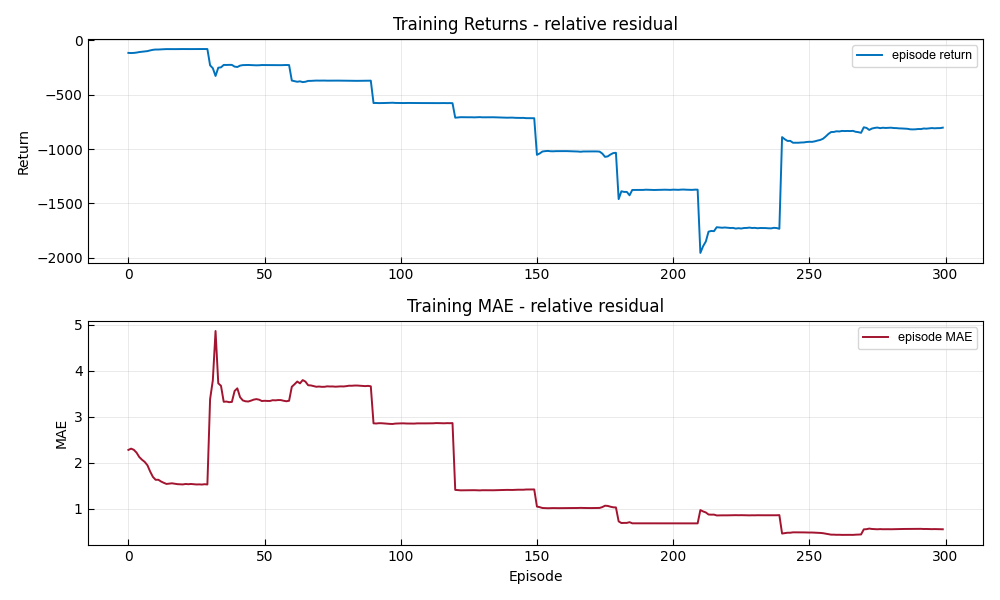

In [7]:
# Default mainline training: relative residual on a simple reference.
relative_config = ExperimentConfig(**cfg.__dict__)
relative_run = train_agent(relative_config, residual_mode="relative", reference_kind=relative_config.reference_kind)
plot_training_history(relative_run["history"], title="relative residual")





# absolute 训练
# absolute_config = ExperimentConfig(**cfg.__dict__)
# absolute_config.reference_kind = "step"
# absolute_run = train_agent(absolute_config, residual_mode="absolute", reference_kind=absolute_config.reference_kind)


# Cell 8: 测试与对比绘图 (注释了 Absolute 训练)


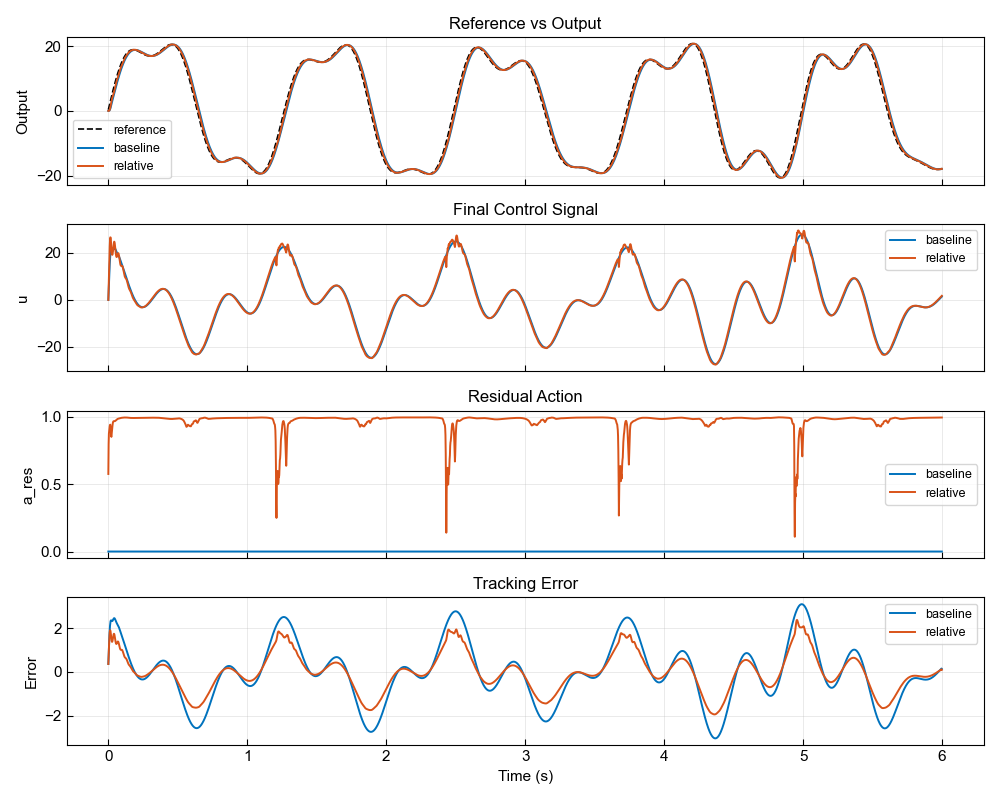

baseline {'mae': 1.0188055038452148, 'rmse': 1.3490957021713257, 'avg_reward': -0.04897544905543327, 'control_variation': 0.21914972364902496, 'residual_magnitude': 0.0}
relative {'mae': 0.654863178730011, 'rmse': 0.8752596378326416, 'avg_reward': -0.03337075933814049, 'control_variation': 0.2562907040119171, 'residual_magnitude': 0.9690986275672913}


In [8]:
# Fixed comparison runs: baseline-only, relative residual, and absolute residual.
# Absolute mode is trained separately so the comparison stays fair.

baseline_history, baseline_metrics = rollout_mode(cfg, agent=None, residual_mode="relative", residual_enabled=False, reference_kind="mixed")
relative_history, relative_metrics = rollout_mode(cfg, agent=relative_run["agent"], residual_mode="relative", residual_enabled=True, reference_kind="mixed")

# absolute_history, absolute_metrics = rollout_mode(cfg, agent=absolute_run["agent"], residual_mode="absolute", residual_enabled=True, reference_kind="mixed")

all_histories = {
    "baseline": baseline_history,
    "relative": relative_history,
    # "absolute": absolute_history,
}
all_metrics = {
    "baseline": baseline_metrics,
    "relative": relative_metrics,
    # "absolute": absolute_metrics,
}
plot_mode_histories(all_histories, all_metrics)

# Cell 9: 模型导出 (无修改)


In [9]:
# import torch
# import torch.nn as nn
# import copy
# from pathlib import Path

# class SimplifiedActorWrapper(nn.Module):
#     def __init__(self, actor):
#         super().__init__()
#         self.actor = actor

#     def forward(self, obs):
#         # 🌟 核心改进：绕过 sample() 逻辑 🌟
#         # 如果 sample() 内部包含 exp(log_std) 或者计算形状的逻辑，R2019a 会报错
#         # 我们直接调用计算 mean 的前向传播路径
#         # 注意：这里的 self.actor.net(obs) 或 self.actor.mu(obs) 需根据你实际模型结构修改
#         try:
#             # 尝试直接获取均值，跳过采样分布的构建
#             mean_action = self.actor.get_action(obs, deterministic=True)
#         except:
#             # 如果没有 get_action，则使用最原始的 forward
#             _, _, mean_action = self.actor.sample(obs, deterministic=True)
#         return mean_action

# def export_for_matlab_2019a(agent, obs_dim, export_dir):
#     export_path = Path(export_dir)
#     export_path.mkdir(parents=True, exist_ok=True)
    
#     # 1. 深度拷贝并设置为评估模式
#     actor_copy = copy.deepcopy(agent.actor)
#     model = SimplifiedActorWrapper(actor_copy).to("cpu").eval()
    
#     # 2. 构造固定维度的输入 (Batch Size 必须固定为 1)
#     dummy_input = torch.randn(1, obs_dim, dtype=torch.float32)
    
#     onnx_path = export_path / "crrl_actor_5.onnx"
    
#     # 3. 导出设置
#     torch.onnx.export(
#         model,
#         dummy_input,
#         str(onnx_path),
#         export_params=True,
#         opset_version=9,          # 🌟 R2019a 的黄金版本
#         do_constant_folding=True, # 🌟 消除 Shape/Expand 的关键
#         input_names=["input_obs"],
#         output_names=["output_action"],
#         # 🌟 绝对不要加 dynamic_axes 🌟
#         verbose=False
#     )
#     print(f"✅ 静态模型已导出至: {onnx_path}")

# # 执行导出
# export_for_matlab_2019a(relative_run["agent"], obs_dim=35, export_dir="exports")

# Cell 10: 扫频信号测试


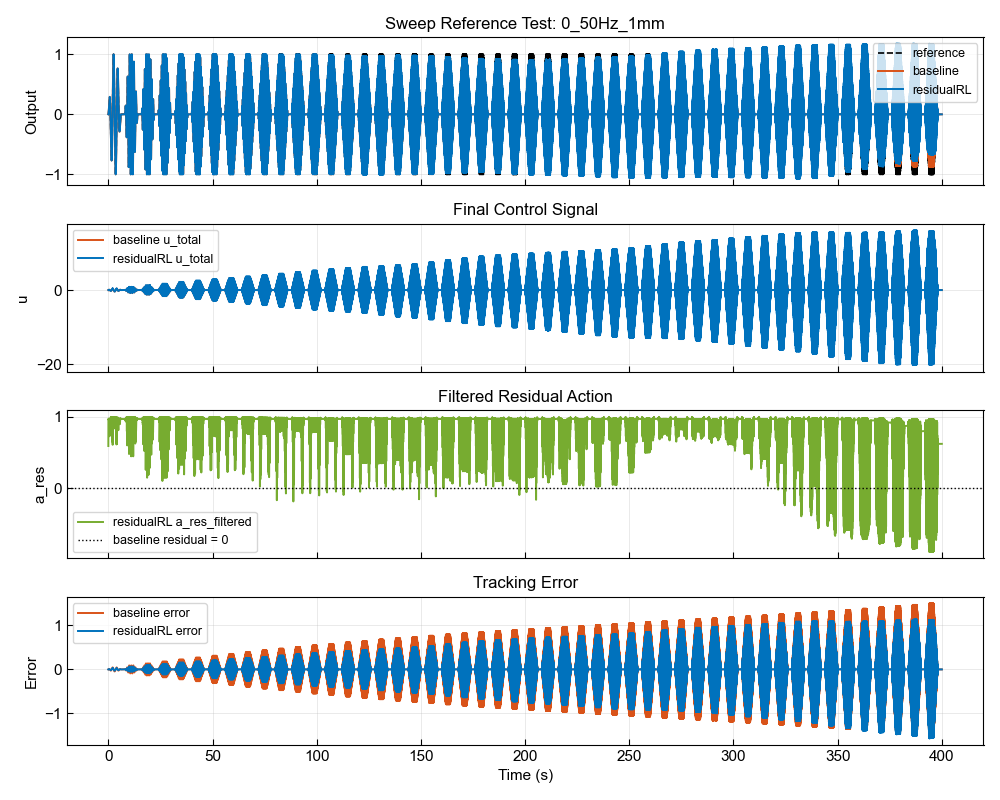

Reference file: reference\0_50Hz_1mm.txt
Sweep tracking metrics
Method        Lag (ms)      Peak Error      RMSE
----------------------------------------------------
baseline         12.000        1.496722   0.429922
residualRL        8.000        1.565320   0.359744
Note: positive lag means the output lags the reference.


In [10]:
reference_path = Path("reference") / "0_50Hz_1mm.txt"
reference_signal = np.loadtxt(reference_path, dtype=np.float32)


def rollout_fixed_reference(config: ExperimentConfig, reference_signal: np.ndarray, agent: SACAgent | None = None,
                            residual_enabled: bool = True, seed_offset: int = 2026):
    test_cfg = ExperimentConfig(**config.__dict__)
    test_cfg.eval_steps = len(reference_signal)
    test_env = build_env(
        test_cfg,
        reference_kind="file",
        residual_mode="relative",
        residual_enabled=residual_enabled,
        reference_signal=reference_signal,
    )

    obs, _ = test_env.reset(seed=test_cfg.seed + seed_offset)
    done = False
    history = {key: [] for key in ["time", "ref", "y", "error", "u_base", "u_total", "a_res", "reward"]}

    while not done:
        if residual_enabled and agent is not None:
            action = agent.act(obs, deterministic=True).astype(np.float32)
        else:
            action = np.zeros((1,), dtype=np.float32)
        obs, reward, terminated, truncated, info = test_env.step(action)
        idx = len(history["time"])
        history["time"].append(idx * test_cfg.dt)
        history["ref"].append(info["ref"])
        history["y"].append(info["y"])
        history["error"].append(info["error"])
        history["u_base"].append(info["u_base"])
        history["u_total"].append(info["u_total"])
        history["a_res"].append(info["a_res_filtered"])
        history["reward"].append(reward)
        done = terminated or truncated

    for key in history:
        history[key] = np.asarray(history[key], dtype=np.float32)
    return history


def compute_tracking_metrics(history: dict, dt: float, max_lag_s: float = 1.0):
    ref = np.asarray(history["ref"], dtype=np.float64)
    y = np.asarray(history["y"], dtype=np.float64)
    error = np.asarray(history["error"], dtype=np.float64)

    n = min(len(ref), len(y))
    ref = ref[:n]
    y = y[:n]
    error = error[:n]

    ref_zero = ref - np.mean(ref)
    y_zero = y - np.mean(y)
    if np.allclose(ref_zero, 0.0) or np.allclose(y_zero, 0.0):
        lag_samples = 0
    else:
        # FFT-based full cross-correlation. Positive lag means output lags reference.
        n_corr = 2 * n - 1
        n_fft = 1 << (n_corr - 1).bit_length()
        corr = np.fft.irfft(
            np.fft.rfft(y_zero, n_fft) * np.fft.rfft(ref_zero[::-1], n_fft),
            n_fft,
        )[:n_corr]
        lags = np.arange(-n + 1, n)
        max_lag_samples = max(1, int(round(max_lag_s / dt)))
        valid = np.abs(lags) <= max_lag_samples
        valid_corr = corr[valid]
        valid_lags = lags[valid]
        lag_samples = int(valid_lags[int(np.argmax(valid_corr))])

    return {
        "time_lag_s": float(lag_samples * dt),
        "time_lag_ms": float(lag_samples * dt * 1000.0),
        "peak_error": float(np.max(np.abs(error))),
        "rmse": float(np.sqrt(np.mean(np.square(error)))),
    }


def print_metric_comparison(title: str, metrics: dict[str, dict]):
    print(title)
    print("Method        Lag (ms)      Peak Error      RMSE")
    print("-" * 52)
    for name, metric in metrics.items():
        print(f"{name:<12s} {metric['time_lag_ms']:>10.3f} {metric['peak_error']:>15.6f} {metric['rmse']:>10.6f}")
    print("Note: positive lag means the output lags the reference.")


file_test_cfg = ExperimentConfig(**cfg.__dict__)
file_test_cfg.eval_steps = len(reference_signal)

sweep_baseline_history = rollout_fixed_reference(
    file_test_cfg,
    reference_signal,
    agent=None,
    residual_enabled=False,
    seed_offset=2026,
)
sweep_residual_history = rollout_fixed_reference(
    file_test_cfg,
    reference_signal,
    agent=relative_run["agent"],
    residual_enabled=True,
    seed_offset=2026,
)

sweep_metrics = {
    "baseline": compute_tracking_metrics(sweep_baseline_history, file_test_cfg.dt),
    "residualRL": compute_tracking_metrics(sweep_residual_history, file_test_cfg.dt),
}

fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
apply_matlab_plot_style(fig, axes)

axes[0].plot(sweep_residual_history["time"], sweep_residual_history["ref"], "k--", linewidth=1.2, label="reference")
axes[0].plot(sweep_baseline_history["time"], sweep_baseline_history["y"], color=MATLAB_COLORS[1], label="baseline")
axes[0].plot(sweep_residual_history["time"], sweep_residual_history["y"], color=MATLAB_COLORS[0], label="residualRL")
axes[0].set_title("Sweep Reference Test: 0_50Hz_1mm")
axes[0].set_ylabel("Output")

axes[1].plot(sweep_baseline_history["time"], sweep_baseline_history["u_total"], color=MATLAB_COLORS[1], label="baseline u_total")
axes[1].plot(sweep_residual_history["time"], sweep_residual_history["u_total"], color=MATLAB_COLORS[0], label="residualRL u_total")
axes[1].set_title("Final Control Signal")
axes[1].set_ylabel("u")

axes[2].plot(sweep_residual_history["time"], sweep_residual_history["a_res"], color=MATLAB_COLORS[4], label="residualRL a_res_filtered")
axes[2].axhline(0.0, color="k", linestyle=":", linewidth=1.0, label="baseline residual = 0")
axes[2].set_title("Filtered Residual Action")
axes[2].set_ylabel("a_res")

axes[3].plot(sweep_baseline_history["time"], sweep_baseline_history["error"], color=MATLAB_COLORS[1], label="baseline error")
axes[3].plot(sweep_residual_history["time"], sweep_residual_history["error"], color=MATLAB_COLORS[0], label="residualRL error")
axes[3].set_title("Tracking Error")
axes[3].set_xlabel("Time (s)")
axes[3].set_ylabel("Error")

for ax in axes:
    ax.legend(loc="best", frameon=True)
plt.tight_layout()
plt.show()

print(f"Reference file: {reference_path}")
print_metric_comparison("Sweep tracking metrics", sweep_metrics)


# Cell 11: 地震波绘图


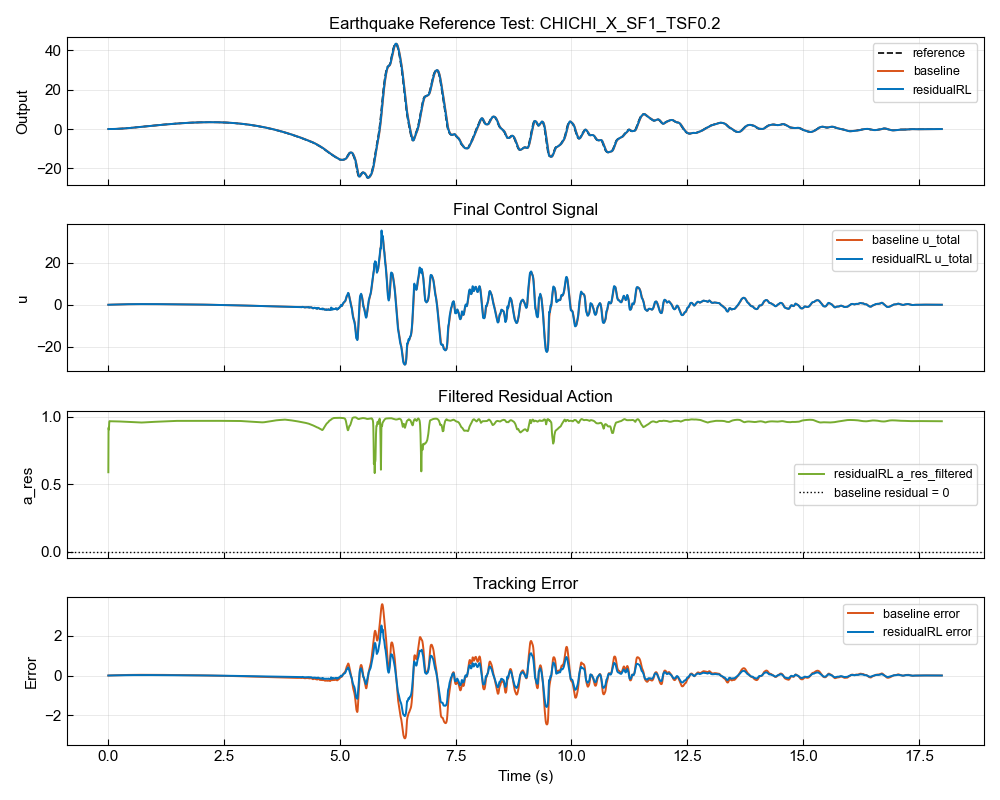

Reference file: 大连理工测试地震波工况\CHICHI_X_SF1_TSF0.2.txt
Earthquake tracking metrics
Method        Lag (ms)      Peak Error      RMSE
----------------------------------------------------
baseline         14.000        3.584032   0.656858
residualRL       10.000        2.512292   0.423749
Note: positive lag means the output lags the reference.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

reference_path = Path("大连理工测试地震波工况") / "CHICHI_X_SF1_TSF0.2.txt"
reference_signal = np.loadtxt(reference_path, dtype=np.float32)


file_test_cfg = ExperimentConfig(**cfg.__dict__)
file_test_cfg.eval_steps = len(reference_signal)

earthquake_baseline_history = rollout_fixed_reference(
    file_test_cfg,
    reference_signal,
    agent=None,
    residual_enabled=False,
    seed_offset=2026,
)
earthquake_residual_history = rollout_fixed_reference(
    file_test_cfg,
    reference_signal,
    agent=relative_run["agent"],
    residual_enabled=True,
    seed_offset=2026,
)

earthquake_metrics = {
    "baseline": compute_tracking_metrics(earthquake_baseline_history, file_test_cfg.dt),
    "residualRL": compute_tracking_metrics(earthquake_residual_history, file_test_cfg.dt),
}

fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
apply_matlab_plot_style(fig, axes)

axes[0].plot(earthquake_residual_history["time"], earthquake_residual_history["ref"], "k--", linewidth=1.2, label="reference")
axes[0].plot(earthquake_baseline_history["time"], earthquake_baseline_history["y"], color=MATLAB_COLORS[1], label="baseline")
axes[0].plot(earthquake_residual_history["time"], earthquake_residual_history["y"], color=MATLAB_COLORS[0], label="residualRL")
axes[0].set_title("Earthquake Reference Test: CHICHI_X_SF1_TSF0.2")
axes[0].set_ylabel("Output")

axes[1].plot(earthquake_baseline_history["time"], earthquake_baseline_history["u_total"], color=MATLAB_COLORS[1], label="baseline u_total")
axes[1].plot(earthquake_residual_history["time"], earthquake_residual_history["u_total"], color=MATLAB_COLORS[0], label="residualRL u_total")
axes[1].set_title("Final Control Signal")
axes[1].set_ylabel("u")

axes[2].plot(earthquake_residual_history["time"], earthquake_residual_history["a_res"], color=MATLAB_COLORS[4], label="residualRL a_res_filtered")
axes[2].axhline(0.0, color="k", linestyle=":", linewidth=1.0, label="baseline residual = 0")
axes[2].set_title("Filtered Residual Action")
axes[2].set_ylabel("a_res")

axes[3].plot(earthquake_baseline_history["time"], earthquake_baseline_history["error"], color=MATLAB_COLORS[1], label="baseline error")
axes[3].plot(earthquake_residual_history["time"], earthquake_residual_history["error"], color=MATLAB_COLORS[0], label="residualRL error")
axes[3].set_title("Tracking Error")
axes[3].set_xlabel("Time (s)")
axes[3].set_ylabel("Error")

for ax in axes:
    ax.legend(loc="best", frameon=True)
plt.tight_layout()
plt.show()

print(f"Reference file: {reference_path}")
print_metric_comparison("Earthquake tracking metrics", earthquake_metrics)
